In [1]:
import time, sys
from  python_modules.UeRanSim import UeRanSim
from  python_modules.Open5GS  import Open5GS
from  python_modules.MonitorScenario  import MonitorScenario
from  python_modules.IperfApp import IperfApp
from  python_modules.Results  import Results

from  python_modules.IperfApp import IperfApp
from  python_modules.Results  import Results


In [2]:

mon    = MonitorScenario()
uersim = UeRanSim(  ["001010000001001"] , "ran" )
iperf  = IperfApp( mon , uersim , apn_mec_name="mec" , apn_mec_ip="10.2.0.1" , apn_cld_name="cld", apn_cld_ip="10.1.0.1" )

iperf.clean_all()
uersim.stop_all_ues()
mon.clean_redis()
mon.start_all_monitors()

mon.start_passmark_test("ran")
time.sleep(5)
mon.stop_passmark_test("ran")

time.sleep(1)

mon.start_passmark_test("mec_host")
time.sleep(5)
mon.stop_passmark_test("mec_host")

time.sleep(1)

mon.start_passmark_test("cld_host")
time.sleep(5)
mon.stop_passmark_test("cld_host")

time.sleep(2)

##########################################
# End simulation and collect results
mon.stop_all_monitors()
res    = Results( f'results/ProvaCPU.json' )
res.collect_and_save_results( mon.redis_cli, mon, iperf )




*** Stop iperf servers
*** Stop iperf clients
*** Stop iperf servers
*** Stop iperf clients
[16:30:49.041629] - Stop All UEs:
*** Save results ... done.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<AxesSubplot:xlabel='Time[s]', ylabel='ReTX'>

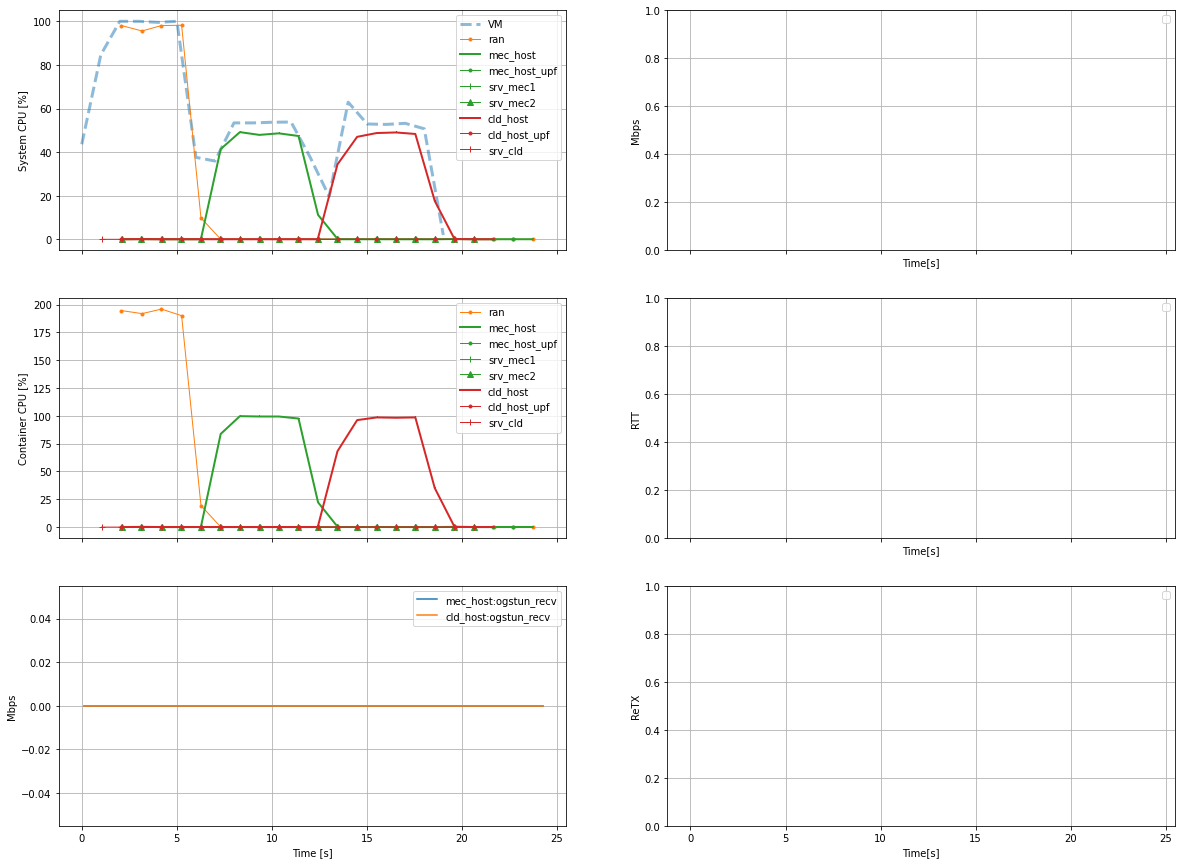

In [3]:
import sys, importlib

import PlotResults.plot_res as p
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

res = p.load_results_json( f'results/ProvaCPU.json' )

fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True , figsize=(20,15) )

p.plot_raw_cont_sys_cpu( res, ax[0][0], scen_idx=2)
p.plot_raw_cont_cpu(     res, ax[1][0], scen_idx=2)
p.plot_raw_upf_thr(      res, ax[2][0])

p.plot_raw_iperf_tcp_mbps_PerUe( res, ax[0][1] , ue="*", colors=p.get_color_list() )
p.plot_raw_iperf_tcp_rtt_PerUe(  res, ax[1][1] , ue="*", colors=p.get_color_list() )
p.plot_raw_iperf_tcp_retx_PerUe( res, ax[2][1] , ue="*", colors=p.get_color_list() )
